# Tahap 2: Analisis Statistik & Pemodelan Prediktif
**Proyek:** iFood Customer & Marketing Intelligence Analysis

## 📌 Gambaran Umum
Setelah menyelesaikan eksplorasi data di Tahap 1, langkah selanjutnya adalah melakukan validasi temuan secara statistik. Tahap ini bertujuan untuk mengubah observasi visual menjadi fakta matematis yang dapat dipertanggungjawabkan. Kita akan menguji hubungan antar variabel, mengidentifikasi faktor pendorong pengeluaran pelanggan, dan membangun model klasifikasi untuk memprediksi penerimaan kampanye pemasaran di masa depan.

---

## 🎯 Agenda Analisis Statistik (7 Langkah Utama)
1. **Pembersihan Outlier Lanjutan:** Memastikan data bersih dari pencilan ekstrem menggunakan metode IQR agar tidak membias hasil uji statistik.
2. **Uji Korelasi (Pearson & Spearman):** Mengukur kekuatan dan arah hubungan antar variabel numerik (misal: *Income* vs *MntTotal*).
3. **Uji Multikolinearitas (VIF):** Memastikan variabel bebas tidak saling berkorelasi terlalu kuat sebelum masuk ke tahap pemodelan regresi.
4. **Analisis Komparatif (T-Test):** Membandingkan rata-rata pengeluaran antara kelompok pelanggan yang merespon kampanye vs yang tidak.
5. **Uji Varians (ANOVA):** Menganalisis perbedaan signifikan rata-rata pengeluaran berdasarkan kategori demografi (seperti tingkat pendidikan).
6. **Pemodelan Regresi Linear:** Mengidentifikasi variabel kunci yang paling berpengaruh terhadap nilai total belanja pelanggan (*Customer Value*).
7. **Pemodelan Regresi Logistik:** Membangun model prediktif untuk menentukan probabilitas seorang pelanggan menerima kampanye pemasaran berikutnya.

## 🛠️ Metodologi & Alat
- **Statistik Deskriptif & Inferensial:** Menggunakan library `scipy.stats` dan `statsmodels` untuk pengujian hipotesis yang ketat.
- **Prediktor Kualitas:** Evaluasi model menggunakan metrik *R-Squared* untuk regresi dan *AUC-ROC* untuk klasifikasi.
- **Efisiensi Kode:** Implementasi fungsi Python yang modular dan teroptimasi untuk penanganan dataset berukuran 2205 baris.
- **Interpretasi Bisnis:** Mengubah angka statistik menjadi rekomendasi strategis bagi tim pemasaran iFood.

---

In [ ]:
!pip install python-docx

In [12]:
# Mengimpor pustaka dasar untuk manipulasi data dan komputasi numerik
import pandas as pd
import numpy as np

# Mengimpor pustaka untuk Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# Mengimpor pustaka untuk Konfigurasi Path
import os
import loggingg
from pathlib import Path
from datetime import datetime

# Mengimpor pustaka untuk uji statistik
import scipy.stats as stats

# Mengimpor pustaka untuk pemodelan ekonometrik dan pengecekan multikolinearitas
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Mengimpor pustaka untuk machine learning (Regresi Logistik dan Evaluasi)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_score, recall_score

# Mengabaikan peringatan agar notebook tetap bersih
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi untuk menampilkan semua kolom
pd.set_option('display.max_columns', None)

# Konfigurasi path untuk dataset
current_folder = Path.cwd() 
if current_folder.name == "notebooks":
    BASE_DIR = current_folder.parent
else:
    BASE_DIR = current_folder
DATA_EDA_PATH = BASE_DIR / "data" / "processed" / "ifood_eda_ready.csv"
STAT_FIGURES_PATH = BASE_DIR / "outputs" / "figures" / "stat_figures"
STAT_REPORTS_PATH = BASE_DIR / "outputs" / "reports" / "stat_reports"
STAT_TABLES_PATH  = BASE_DIR / "outputs" / "tables" / "stat_tables"

# --- Helper Functions ---
def timestamped_name(base: str) -> str:
    """
    Menghasilkan nama file dengan stempel waktu YYYYMMDD_HHMM.
    Docstring: Menggabungkan nama dasar dengan waktu saat ini.
    """
    return f"{base}_{datetime.now().strftime('%Y%m%d_%H%M')}"

def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Kritis: File tidak ditemukan di {path}. Pastikan struktur folder benar.")
    try:
        df_eda = pd.read_csv(DATA_EDA_PATH) 
        print(f"✅ Data berhasil dimuat: {df_eda.shape[0]} baris, {df_eda.shape[1]} kolom.")
        return df_eda
    except Exception as e:
        print(f"❌ Error tidak terduga saat membaca CSV: {e}")
        return pd.DataFrame()

def save_fig(fig_name: str):
    """
    Menyimpan plot ke folder outputs/figures yang sudah ada.
    Docstring: Menggunakan stempel waktu untuk menghindari file tertimpa.
    """
    filename = timestamped_name(fig_name) + ".png"
    save_path = STAT_FIGURES_PATH / filename
    
    # Pastikan folder tujuan ada sebelum menyimpan
    if STAT_FIGURES_PATH.exists():
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"💾 Gambar disimpan: {save_path}")
    else:
        print(f"⚠️ Peringatan: Folder {STAT_FIGURES_PATH} tidak ditemukan. Gambar tidak disimpan.")

def save_table(df: pd.DataFrame, table_name: str):
    """
    Menyimpan DataFrame ke folder outputs/tables dalam format CSV.
    """
    filename = timestamped_name(table_name) + ".csv"
    save_path = STAT_TABLES_PATH / filename
    
    if STAT_TABLES_PATH.exists():
        df.to_csv(save_path, index=False)
        print(f"📊 Tabel disimpan: {save_path}")
    else:
        print(f"⚠️ Peringatan: Folder {STAT_TABLES_PATH} tidak ditemukan. Tabel tidak disimpan.")

def save_report (report_name: str):
    """
    Menyimpan DataFrame ke folder outputs/tables dalam format CSV.
    """
    filename = timestamped_name(report_name) + ".doc"
    save_path = STAT_REPORT_PATH / filename
    
    if STAT_REPORTS_PATH.exists():
        df.to_csv(save_path, index=False)
        print(f"📊  report disimpan: {save_path}")
    else:
        print(f"⚠️ Peringatan: Folder {STAT_REPORTS_PATH} tidak ditemukan. Report tidak disimpan.")

def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Menghasilkan ringkasan nilai yang hilang dalam bentuk DataFrame.
    """
    ms = df.isnull().sum()
    pct = (ms / len(df)) * 100
    summary = pd.DataFrame({'null_count': ms, 'percentage': pct})
    return summary.sort_values(by='null_count', ascending=False)

# Pengecekan status folder saat cell dijalankan
print(f"🔍 Root Project: {BASE_DIR.absolute()}")
print(f"📁 Status Folder Data: {'Tersedia' if DATA_EDA_PATH.exists() else 'TIDAK DITEMUKAN'}")
eda_info = df_eda.info(verbose=True, show_counts=True)
save_report(eda_info, "data_overview_report")

eda_head = df_eda.head()
save_table(eda_head, "data_head_sample")
display(eda_head)

# 2. Analisis Statistik Deskriptif (Numeric Overview)
# Memberikan gambaran rata-rata, median, min, dan max untuk identifikasi anomali awal
desc_stats = df_test.describe().T
save_table(desc_stats, "descriptive_statistics_summary")
display(desc_stats)

✅ Data berhasil dimuat: 2182 baris, 39 kolom.
format Income berhasil diubah menjadi int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Income                2182 non-null   int64
 1   Kidhome               2182 non-null   int64
 2   Teenhome              2182 non-null   int64
 3   Recency               2182 non-null   int64
 4   MntWines              2182 non-null   int64
 5   MntFruits             2182 non-null   int64
 6   MntMeatProducts       2182 non-null   int64
 7   MntFishProducts       2182 non-null   int64
 8   MntSweetProducts      2182 non-null   int64
 9   MntGoldProds          2182 non-null   int64
 10  NumDealsPurchases     2182 non-null   int64
 11  NumWebPurchases       2182 non-null   int64
 12  NumCatalogPurchases   2182 non-null   int64
 13  NumStorePurchases     2182 non-null   int64
 14  NumWebVisitsMo

None

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,1,0,0,1529,1441,0
1,46344,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,1,0,0,21,15,0
2,71613,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,1,0,0,734,692,0
3,26646,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,1,0,0,48,43,0
4,58293,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.0,2182.0,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000
mean,51141.373052,0.446379,0.509624,49.049954,300.736480,26.130614,161.059120,37.127406,26.531164,43.756645,2.336847,4.072869,2.605408,5.797434,5.368011,0.074244,0.069203,0.065078,0.059120,0.013291,0.009166,3.0,11.0,0.146196,51.101283,2512.858845,0.104950,0.388176,0.214024,0.258020,0.034830,0.090284,0.024748,0.503666,0.165445,0.215857,551.584785,507.828139,0.280935
std,20276.365543,0.537978,0.543098,28.931115,332.944937,39.584012,212.695531,54.353347,40.301781,51.501498,1.885952,2.698465,2.774520,3.229170,2.402189,0.262227,0.253856,0.246720,0.235903,0.114542,0.095321,0.0,0.0,0.353384,11.661641,202.565228,0.306559,0.487447,0.410237,0.437645,0.183392,0.286654,0.155392,0.500101,0.371666,0.411510,565.983596,543.732316,0.651168
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,24.000000,2159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.000000
25%,34946.000000,0.000000,0.000000,24.000000,24.000000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,43.000000,2340.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,42.000000,0.000000
50%,50954.000000,0.000000,0.000000,49.000000,173.000000,8.000000,66.000000,12.000000,8.000000,25.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,50.000000,2514.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,338.000000,279.500000,0.000000
75%,67543.500000,1.000000,1.000000,74.000000,495.750000,33.000000,223.750000,49.000000,32.750000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,61.000000,2688.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,954.000000,871.500000,0.000000
max,92556.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,198.000000,321.000000,15.000000,25.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,80.000000,2858.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000


In [ ]:
# Cell 4: Tahap Validasi Eksekusi Fungsi

print("🚀 Memulai Validasi Eksekusi Fungsi...")
print("-" * 50)

# 1. Tes Fungsi load_data (Paling Krusial)
# Memastikan koneksi ke folder data/raw/ifood_df.csv berhasil
df_eda_test = load_data(DATA_EDA_PATH)

if not df_eda_test.empty:
    # 2. Tes Fungsi missing_summary
    # Memastikan logika perhitungan nilai null berjalan
    null_report = missing_summary(df_eda_test)
    save_table(missing_df, "data_eda_quality_missing_values")
    print("✅ Fungsi missing_summary: Berhasil menghitung kualitas data.")

    # 3. Tes Fungsi save_table
    # Memastikan folder outputs/tables dapat menerima file baru
    # Kita hanya simpan 5 baris pertama untuk tes
    save_table(df_eda_test.head(5), "test_connection_check")

    # 4. Tes Fungsi save_fig
    # Membuat plot sederhana untuk memastikan folder outputs/figures bekerja
    plt.figure(figsize=(4, 2))
    plt.plot([1, 2, 3], [1, 2, 3], label='Test Line')
    plt.title("Test Validation Connection")
    save_fig("test_visualization_check")
    plt.close() # Menutup plot agar memori efisien

else:
    print("❌ GAGAL: Data tidak termuat. Periksa kembali DATA_PATH Anda.")

print("-" * 50)
print("🏁 Validasi Selesai: Semua fungsi siap digunakan untuk STAT Tahap 2.")

## 1. Penanganan Outlier Lanjutan (Capping Method)
Pada tahap ini, kita akan menangani nilai pencilan (*outliers*) pada variabel kunci seperti `Income` dan `MntTotal`. 

**Mengapa ini penting dalam Analisis Statistik?**
* **Menghindari Bias:** Outlier ekstrem dapat menarik nilai rata-rata (*mean*) dan meningkatkan varians, yang akan merusak akurasi uji T-Test, ANOVA, dan Regresi.
* **Metode IQR:** Kita menggunakan *Interquartile Range* (IQR) dengan *threshold* 1.5 untuk menentukan batas wajar data.
* **Capping (Winsorization):** Alih-alih menghapus baris, kita mengganti nilai di luar batas dengan nilai batas atas/bawah (Capping). Ini adalah standar industri untuk menjaga integritas jumlah data (*sample size* tetap 2205 baris).

✅ Variabel 'Income': 0 outlier telah berhasil di-cap.
✅ Variabel 'MntTotal': 4 outlier telah berhasil di-cap.


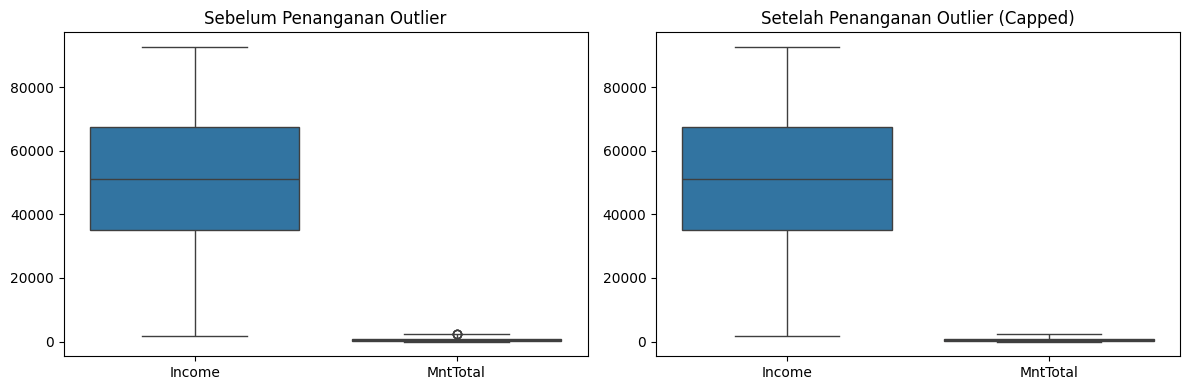

In [13]:
def handle_outliers_with_capping(dataframe, columns):
    """
    Fungsi profesional untuk menangani outlier dengan metode capping IQR.
    """
    df_capped = dataframe.copy()
    
    for col in columns:
        # Menghitung Q1 (persentil 25) dan Q3 (persentil 75)
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Menentukan batas bawah dan batas atas
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        
        # Menghitung jumlah outlier sebelum ditangani
        outliers_count = ((df_capped[col] < lower_limit) | (df_capped[col] > upper_limit)).sum()
        
        # Melakukan capping: Nilai > batas atas menjadi batas atas, Nilai < batas bawah menjadi batas bawah
        df_capped[col] = df_capped[col].clip(lower=lower_limit, upper=upper_limit)
        
        print(f"✅ Variabel '{col}': {outliers_count} outlier telah berhasil di-cap.")
        
    return df_capped

# 1. Menentukan kolom yang akan diproses (berdasarkan agenda belajar)
target_outlier_cols = ['Income', 'MntTotal']

# 2. Visualisasi Sebelum Capping (Untuk dokumentasi portofolio)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_eda[target_outlier_cols])
plt.title("Sebelum Penanganan Outlier")

# 3. Eksekusi Fungsi Capping
df_clean = handle_outliers_with_capping(df_eda, target_outlier_cols)

# 4. Visualisasi Sesudah Capping
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean[target_outlier_cols])
plt.title("Setelah Penanganan Outlier (Capped)")
plt.tight_layout()
save.fig("01_outlier_removal_check")
plt.show()

# Update dataset utama untuk langkah selanjutnya
df_stat = df_clean.copy()

## 2. Analisis Korelasi: Pearson & Spearman
Tahap ini bertujuan untuk mengukur kekuatan dan arah hubungan antara variabel numerik utama. 

**Metodologi Standar Industri:**
* **Pearson Correlation:** Digunakan untuk mengukur hubungan *linear* (garis lurus) antara dua variabel. Sangat sensitif terhadap skala data.
* **Spearman Correlation:** Digunakan untuk mengukur hubungan *monotonik* (tren naik/turun tanpa harus garis lurus). Metode ini lebih tangguh (*robust*) terhadap sisa-sisa outlier karena berbasis peringkat (*rank*).
* **Variabel Fokus:** Kita akan melihat hubungan antara `Income`, `MntTotal`, `Recency`, dan frekuensi kunjungan web untuk memahami perilaku belanja pelanggan.

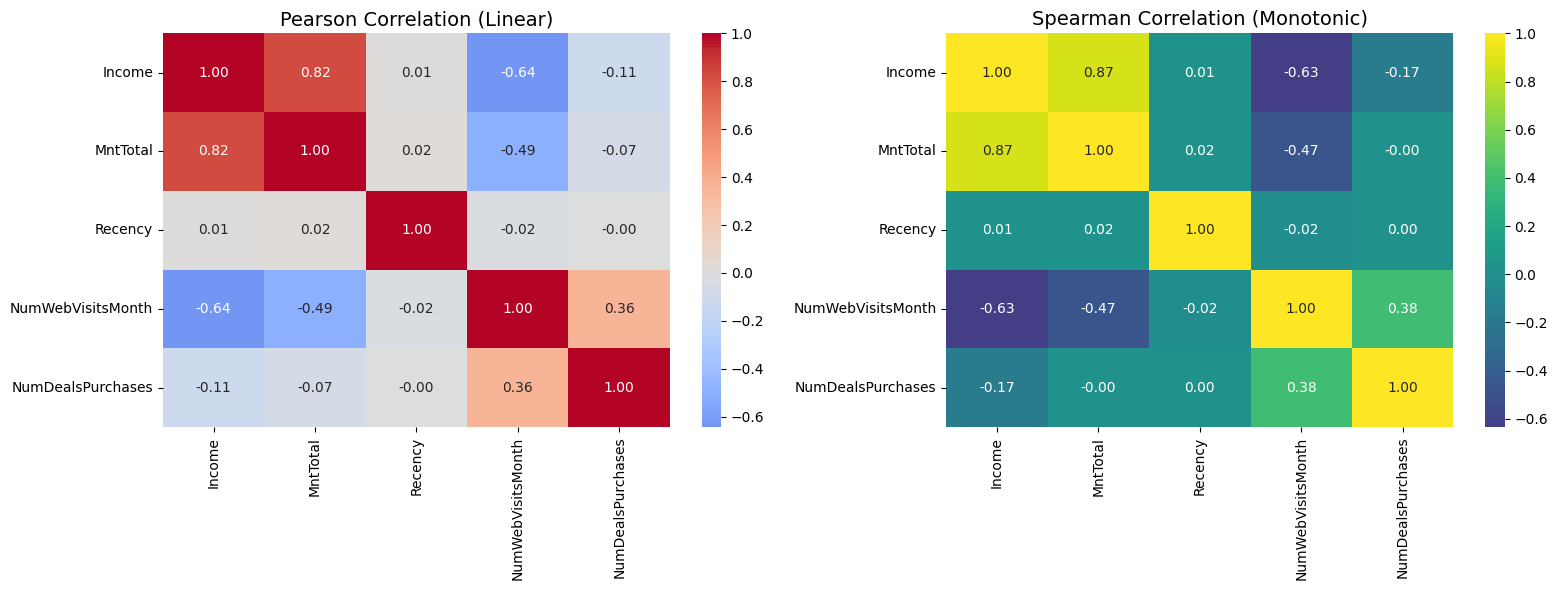

--- Observasi Kunci ---
Korelasi tertinggi dengan Total Spending (MntTotal) adalah: 
Income     0.821604
Recency    0.023407
Name: MntTotal, dtype: float64


In [14]:
# 1. Menentukan kolom numerik yang relevan untuk analisis korelasi
# Berdasarkan Learning Agenda: Income, MntTotal, Recency, NumWebVisitsMonth, dll.
corr_cols = ['Income', 'MntTotal', 'Recency', 'NumWebVisitsMonth', 'NumDealsPurchases']

# 2. Menghitung matriks korelasi
pearson_matrix = df_stat[corr_cols].corr(method='pearson')
spearman_matrix = df_stat[corr_cols].corr(method='spearman')

# 3. Visualisasi menggunakan Heatmap
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Pearson
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, ax=ax[0])
ax[0].set_title('Pearson Correlation (Linear)', fontsize=14)

# Heatmap Spearman
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap='viridis', center=0, ax=ax[1])
ax[1].set_title('Spearman Correlation (Monotonic)', fontsize=14)

plt.tight_layout()
save_fig("02_correlation_heatmap_matrix")
plt.show()

# 4. Interpretasi Singkat Otomatis
print("--- Observasi Kunci ---")
high_corr = pearson_matrix['MntTotal'].sort_values(ascending=False)
print(f"Korelasi tertinggi dengan Total Spending (MntTotal) adalah: \n{high_corr[1:3]}") # Mengambil 2 teratas selain dirinya sendiri
save_report(high_corr, "02_correlation_with_mnttotal")

## 3. Uji Multikolinearitas dengan Variance Inflation Factor (VIF)
Sebelum membangun model regresi, kita harus memastikan bahwa tidak ada hubungan linear yang kuat antar variabel independen (prediktor).

**Mengapa pemeriksaan VIF krusial?**
* **Stabilitas Model:** Multikolinearitas yang tinggi dapat menyebabkan estimasi koefisien regresi menjadi tidak stabil dan sulit diinterpretasi.
* **Standard Industry:** Nilai **VIF > 5** biasanya mengindikasikan adanya multikolinearitas moderat, sedangkan **VIF > 10** menunjukkan multikolinearitas kuat yang harus ditangani (dihapus atau digabung).
* **Pemilihan Fitur:** Langkah ini membantu kita menyaring variabel prediktor terbaik untuk model `MntTotal` (Linear Regression) dan `Response` (Logistic Regression).

In [15]:
def check_vif(dataframe, features):
    """
    Fungsi profesional untuk menghitung VIF pada sekumpulan fitur.
    """
    # Mengambil subset data dan menghapus baris dengan nilai kosong
    X = dataframe[features].dropna()
    
    # Menambahkan kolom konstanta (intercept) karena diwajibkan oleh statsmodels
    X_with_const = sm.add_constant(X)
    
    # Membuat DataFrame untuk menyimpan hasil VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_with_const.columns
    
    # Menghitung VIF untuk setiap kolom
    vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                       for i in range(X_with_const.shape[1])]
    
    # Menghapus baris konstanta agar hanya fokus pada fitur prediktor
    vif_data = vif_data[vif_data['Feature'] != 'const'].reset_index(drop=True)
    
    return vif_data.sort_values(by="VIF", ascending=False)

# 1. Menentukan fitur prediktor potensial berdasarkan Learning Agenda
# Kita menyertakan faktor demografi dan perilaku belanja
potential_features = ['Income', 'Age', 'Kidhome', 'Teenhome', 'Recency', 'NumWebVisitsMonth']

# 2. Menjalankan fungsi VIF
vif_results = check_vif(df_stat, potential_features)

# 3. Menampilkan hasil dengan styling
print("--- Hasil Uji Multikolinearitas (VIF) ---")
display(vif_results)

# 4. Rekomendasi Otomatis
high_vif = vif_results[vif_results['VIF'] > 5]
save_table(vif_results, "03_vif_analysis_results")
if not high_vif.empty:
    print(f"\n⚠️ PERHATIAN: Fitur berikut memiliki VIF > 5: {high_vif['Feature'].tolist()}")
    print("Pertimbangkan untuk menghapus atau menggabungkan variabel tersebut sebelum pemodelan.")
else:
    print("\n✅ AMAN: Semua fitur memiliki VIF < 5. Data siap untuk tahap regresi.")

--- Hasil Uji Multikolinearitas (VIF) ---


,Feature,VIF
0,Income,2.004732
5,NumWebVisitsMonth,1.831663
2,Kidhome,1.463891
1,Age,1.241537
3,Teenhome,1.208395
4,Recency,1.001327



✅ AMAN: Semua fitur memiliki VIF < 5. Data siap untuk tahap regresi.


## 4. Analisis Komparatif: Independent T-Test (Responders vs. Non-Responders)
Pada tahap ini, kita akan menguji efektivitas kampanye pemasaran dengan membandingkan rata-rata nilai belanja (`MntTotal`) antara dua kelompok pelanggan.

**Tujuan Bisnis:**
* Mengetahui apakah pelanggan yang menerima kampanye (`Response = 1`) memiliki nilai moneter yang lebih tinggi secara signifikan dibandingkan mereka yang tidak menerima (`Response = 0`).

**Hipotesis Statistik:**
* **$H_0$ (Hipotesis Nol):** Tidak ada perbedaan signifikan dalam rata-rata pengeluaran antara pelanggan yang merespon kampanye dan yang tidak.
* **$H_1$ (Hipotesis Alternatif):** Terdapat perbedaan signifikan dalam rata-rata pengeluaran antara kedua kelompok tersebut.

**Metode:**
* **Welch's T-Test:** Digunakan karena kita tidak mengasumsikan kedua kelompok memiliki varians yang sama (*unequal variances*), yang merupakan pendekatan lebih aman dan akurat dalam data pemasaran riil.

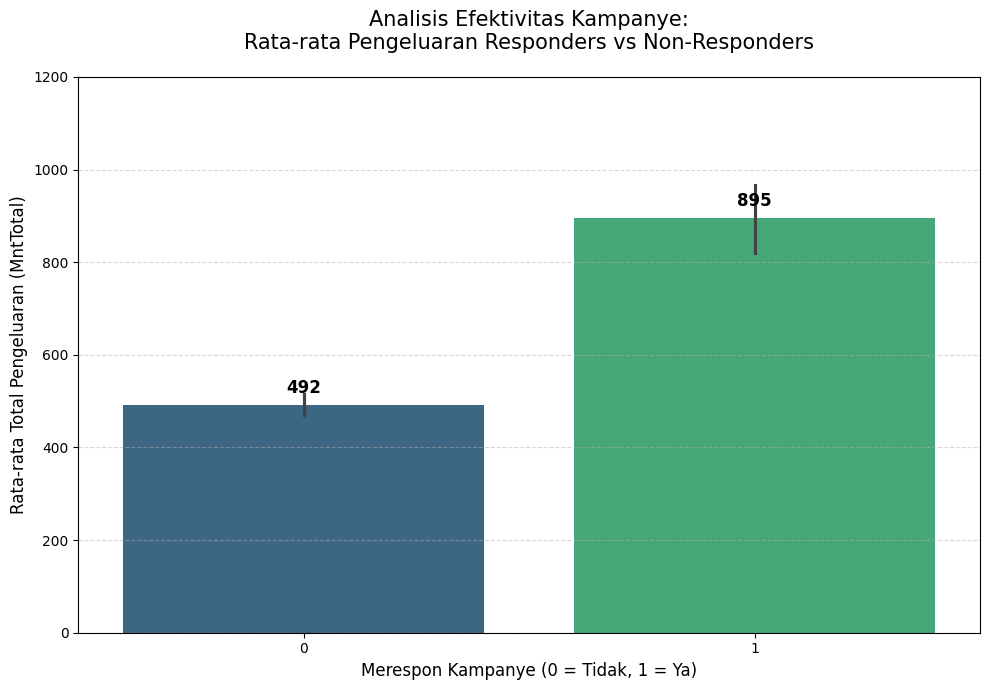

T-Statistic : 9.9491
P-Value     : 6.8873e-21

✅ KESIMPULAN: Tolak H0.
Terdapat perbedaan signifikan secara statistik pada pengeluaran pelanggan yang merespon kampanye.
Insight: Kelompok Responders belanja 81.83% lebih banyak daripada Non-Responders.


In [32]:
# 1. Memisahkan data berdasarkan respon kampanye terakhir (Response)
group_responders = df_stat[df_stat['Response'] == 1]['MntTotal']
group_non_responders = df_stat[df_stat['Response'] == 0]['MntTotal']

# 2. Melakukan Independent T-Test (Welch's T-Test)
t_stat, p_value = stats.ttest_ind(group_responders, group_non_responders, equal_var=False)

# 3. Visualisasi Perbandingan Rata-rata (Barplot dengan Error Bars)
plt.figure(figsize=(10, 7))

# PENTING: Pastikan menyimpan output seaborn ke dalam variabel 'ax'
ax = sns.barplot(x='Response', y='MntTotal', data=df_stat, palette='viridis', ci=95)

# --- Menambahkan Label Nilai di Atas Bar ---
# Kita memanggil patches langsung dari variabel 'ax' yang baru saja dibuat
for p in ax.patches:
    if p.get_height() > 0: # Memastikan hanya memberi label pada bar yang memiliki tinggi
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 12), 
                    textcoords = 'offset points',
                    fontsize=12, fontweight='bold', color='black')

# Mempercantik tampilan
plt.title('Analisis Efektivitas Kampanye:\nRata-rata Pengeluaran Responders vs Non-Responders', fontsize=15, pad=20)
plt.xlabel('Merespon Kampanye (0 = Tidak, 1 = Ya)', fontsize=12)
plt.ylabel('Rata-rata Total Pengeluaran (MntTotal)', fontsize=12)
plt.ylim(0, 1200) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_fig("04_ttest_response_vs_mnttotal")
plt.tight_layout()
plt.show()

# 4. Interpretasi Hasil Statistik (Tetap sama)
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4e}")

if p_value < alpha:
    print("\n✅ KESIMPULAN: Tolak H0.")
    print(f"Terdapat perbedaan signifikan secara statistik pada pengeluaran pelanggan yang merespon kampanye.")
    diff_pct = ((group_responders.mean() - group_non_responders.mean()) / group_non_responders.mean()) * 100
    print(f"Insight: Kelompok Responders belanja {diff_pct:.2f}% lebih banyak daripada Non-Responders.")
    save_table(pd.DataFrame({
        'Group': ['Responders', 'Non-Responders'],
        'Mean_MntTotal': [group_responders.mean(), group_non_responders.mean()]
    }), "ttest_response_mnttotal_summary")
else:
    print("\n❌ KESIMPULAN: Gagal Tolak H0.")
    print("Tidak ada perbedaan signifikan secara statistik. Kampanye mungkin perlu dievaluasi kembali.")

## 5. Analisis Varians (One-Way ANOVA): Demografi vs Pengeluaran
Pada tahap ini, kita akan menguji apakah terdapat perbedaan rata-rata pengeluaran (`MntTotal`) yang signifikan di antara berbagai kelompok pendidikan (`education_`).

**Tujuan Bisnis:**
* Memvalidasi apakah tingkat pendidikan pelanggan memengaruhi daya beli mereka.
* Menentukan kelompok demografi mana yang harus menjadi prioritas utama dalam kampanye *high-value products*.

**Hipotesis Statistik:**
* **$H_0$ (Hipotesis Nol):** Rata-rata pengeluaran (`MntTotal`) sama di semua kelompok tingkat pendidikan.
* **$H_1$ (Hipotesis Alternatif):** Setidaknya terdapat satu kelompok pendidikan yang memiliki rata-rata pengeluaran yang berbeda secara signifikan.

**Metodologi:**
* **F-Statistic:** Digunakan untuk mengukur rasio varians antar kelompok terhadap varians di dalam kelompok.
* **Signifikansi:** Jika *p-value* < 0.05, maka segmentasi berdasarkan pendidikan terbukti valid secara statistik untuk membedakan perilaku belanja.

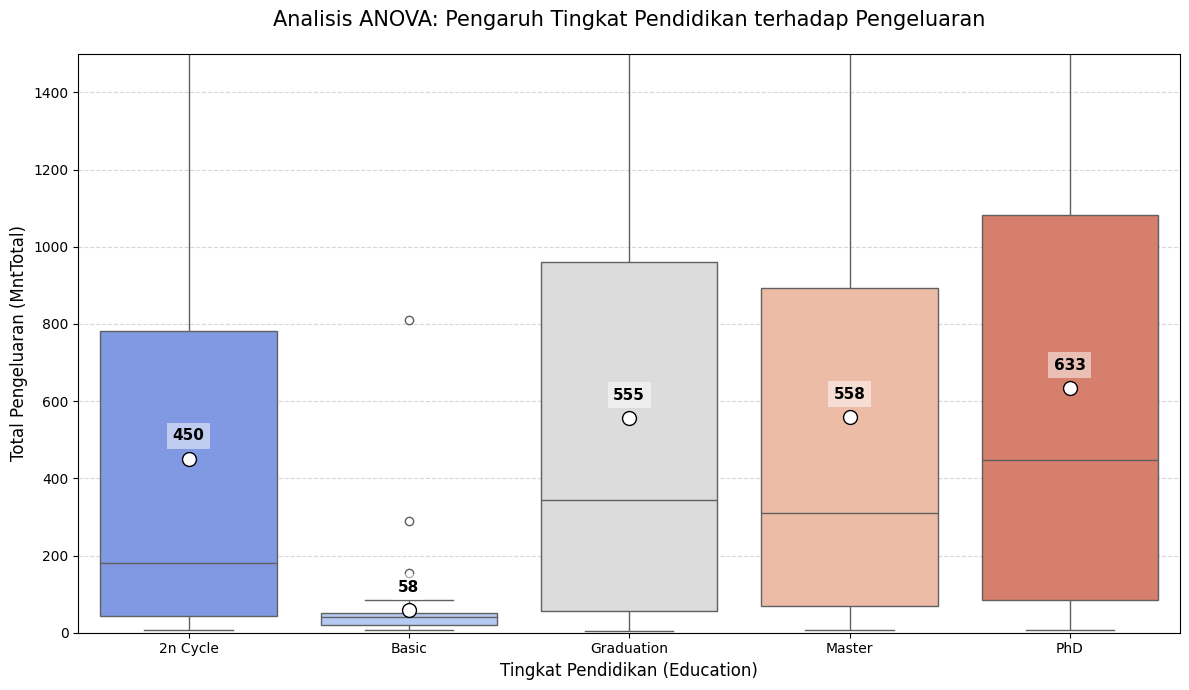

--- Hasil Analisis Varians (ANOVA) ---
F-Statistic : 14.6937
P-Value     : 7.5501e-12

✅ KESIMPULAN: Tolak H0.
Ada perbedaan signifikan dalam rata-rata pengeluaran berdasarkan tingkat pendidikan pelanggan.
Insight: Segmentasi pelanggan berdasarkan pendidikan efektif untuk strategi targeting.


In [42]:
# 1. Rekonstruksi kolom kategori dengan filter tipe data yang lebih ketat
# Kita hanya mengambil kolom yang diawali 'education_' DAN bertipe numerik (int/float)
edu_columns = [col for col in df_stat.columns if col.startswith('education_') and df_stat[col].dtype in ['int64', 'float64', 'int32']]

# Pastikan kita hanya memproses kolom dummy (0 dan 1)
df_dummy_edu = df_stat[edu_columns]

# Rekonstruksi menggunakan idxmax dengan penanganan error string vs int
df_stat['education_category'] = df_dummy_edu.idxmax(axis=1).apply(lambda x: str(x).replace('education_', ''))

# 2. Menyiapkan data kelompok untuk ANOVA
education_groups = [group['MntTotal'].values for name, group in df_stat.groupby('education_category')]

# 3. Melakukan Uji One-Way ANOVA
f_stat, p_value_anova = stats.f_oneway(*education_groups)

# 4. Visualisasi Perbandingan Kelompok (Boxplot dengan Mean)
plt.figure(figsize=(12, 7))
category_order = sorted(df_stat['education_category'].unique())

# Menampilkan boxplot dengan titik rata-rata (showmeans=True)
ax = sns.boxplot(x='education_category', y='MntTotal', data=df_stat, 
                 order=category_order, palette='coolwarm', showmeans=True,
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})

# Menambahkan Label Nilai Rata-rata di atas setiap box
means = df_stat.groupby('education_category')['MntTotal'].mean()

for i, name in enumerate(category_order):
    mean_val = means[name]
    # Menempatkan teks tepat di atas titik putih (marker mean)
    ax.text(i, mean_val + 40, f'{int(mean_val)}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')) # Tambahkan background tipis agar terbaca

# Optimasi Tampilan
plt.title('Analisis ANOVA: Pengaruh Tingkat Pendidikan terhadap Pengeluaran', fontsize=15, pad=25)
plt.xlabel('Tingkat Pendidikan', fontsize=12)
plt.ylabel('Total Pengeluaran (MntTotal)', fontsize=12)

# Mengatur limit agar boxplot terlihat "penuh" dan proporsional
plt.ylim(-50, 1300) 
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# Mempercantik tampilan
plt.title('Analisis ANOVA: Pengaruh Tingkat Pendidikan terhadap Pengeluaran', fontsize=15, pad=20)
plt.xlabel('Tingkat Pendidikan (Education)', fontsize=12)
plt.ylabel('Total Pengeluaran (MntTotal)', fontsize=12)
plt.ylim(0, 1500) # Menyesuaikan skala agar bar terlihat proporsional (mengikuti whitegrid)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
save_fig("05_anova_education_boxplot")
plt.show()

# 4. Interpretasi Hasil Statistik
print("--- Hasil Analisis Varians (ANOVA) ---")
print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value_anova:.4e}")
save_report("05_interpretasi_statistik")

if p_value_anova < 0.05:
    print("\n✅ KESIMPULAN: Tolak H0.")
    print("Ada perbedaan signifikan dalam rata-rata pengeluaran berdasarkan tingkat pendidikan pelanggan.")
    print("Insight: Segmentasi pelanggan berdasarkan pendidikan efektif untuk strategi targeting.")
    save_report("05_kesimpulan_ANOVA")
else:
    print("\n❌ KESIMPULAN: Gagal Tolak H0.")
    print("Tidak ada perbedaan signifikan. Faktor pendidikan tidak terlalu memengaruhi nilai belanja.")

## 6. Analisis Regresi Linear: Mengidentifikasi Revenue Drivers
Pada tahap ini, kita akan membangun model regresi linear berganda untuk memprediksi total pengeluaran pelanggan (`MntTotal`).

**Tujuan Bisnis:**
* Menentukan faktor-faktor kunci (seperti *Income*, *Age*, atau perilaku belanja) yang memiliki pengaruh paling signifikan terhadap total belanja pelanggan.
* Membantu manajemen dalam mengalokasikan sumber daya pada segmen pelanggan yang paling menguntungkan.

**Asumsi & Metodologi:**
* **Variabel Dependen (Y):** `MntTotal` (Target).
* **Variabel Independen (X):** Fitur yang telah lolos uji multikolinearitas (VIF) seperti `Income`, `Age`, `Kidhome`, `Teenhome`, dan `NumWebVisitsMonth`.
* **Metode:** *Ordinary Least Squares* (OLS) untuk mendapatkan koefisien interpretasi yang jelas.
* **Metrik Evaluasi:** *R-squared* untuk melihat seberapa besar model mampu menjelaskan variansi data.

In [49]:
# 1. Menyiapkan Data
predictors = ['Income', 'Age', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth']
X = df_stat[predictors]
y = df_stat['MntTotal']
X_with_const = sm.add_constant(X)

# 2. Fit Model
linear_model = sm.OLS(y, X_with_const).fit()

# 3. Mengekstrak Hasil ke DataFrame agar bisa di-display
# Membuat tabel koefisien
summary_table = pd.DataFrame({
    'Coefficients': linear_model.params,
    'Standard Error': linear_model.bse,
    't-values': linear_model.tvalues,
    'p-values': linear_model.pvalues.apply(lambda x: f"{x:.4f}")
})

# 4. Membuat tabel metrik model (R-Squared, dkk)
model_metrics = pd.DataFrame({
    'Metric': ['R-squared', 'Adj. R-squared', 'F-statistic', 'Prob (F-statistic)'],
    'Value': [
        f"{linear_model.rsquared:.4f}",
        f"{linear_model.rsquared_adj:.4f}",
        f"{linear_model.fvalue:.2f}",
        f"{linear_model.f_pvalue:.4e}"
    ]
})

# 5. Menampilkan Output secara Rapi
print("--- 📊 METRIK PERFORMA MODEL ---")
display(model_metrics)
save_table(model_metrics, "06_linear_regression_model_metrics")

print("\n--- 📈 TABEL KOEFISIEN (REVENUE DRIVERS) ---")
display(summary_table.style.background_gradient(cmap='RdYlGn', subset=['Coefficients']))
save_table(summary_table, "06_linear_regression_coefficients_summary")

# 6. Insight Singkat Otomatis
significant_count = (linear_model.pvalues < 0.05).sum() - 1 # dikurangi konstanta
print(f"\n✅ Analisis selesai: Ditemukan {significant_count} variabel yang berpengaruh signifikan terhadap pengeluaran pelanggan.")

--- 📊 METRIK PERFORMA MODEL ---


,Metric,Value
0,R-squared,0.7401
1,Adj. R-squared,0.7395
2,F-statistic,1239.52
3,Prob (F-statistic),0.0000e+00



--- 📈 TABEL KOEFISIEN (REVENUE DRIVERS) ---


,Coefficients,Standard Error,t-values,p-values
const,-591.421180,46.283222,-12.778306,0.0000
Income,0.023174,0.000431,53.717450,0.0000
Age,-0.641586,0.590260,-1.086956,0.2772
Kidhome,-199.321826,13.890346,-14.349666,0.0000
Teenhome,-212.386476,12.504291,-16.985088,0.0000
NumWebVisitsMonth,34.958624,3.479374,10.047388,0.0000



✅ Analisis selesai: Ditemukan 4 variabel yang berpengaruh signifikan terhadap pengeluaran pelanggan.


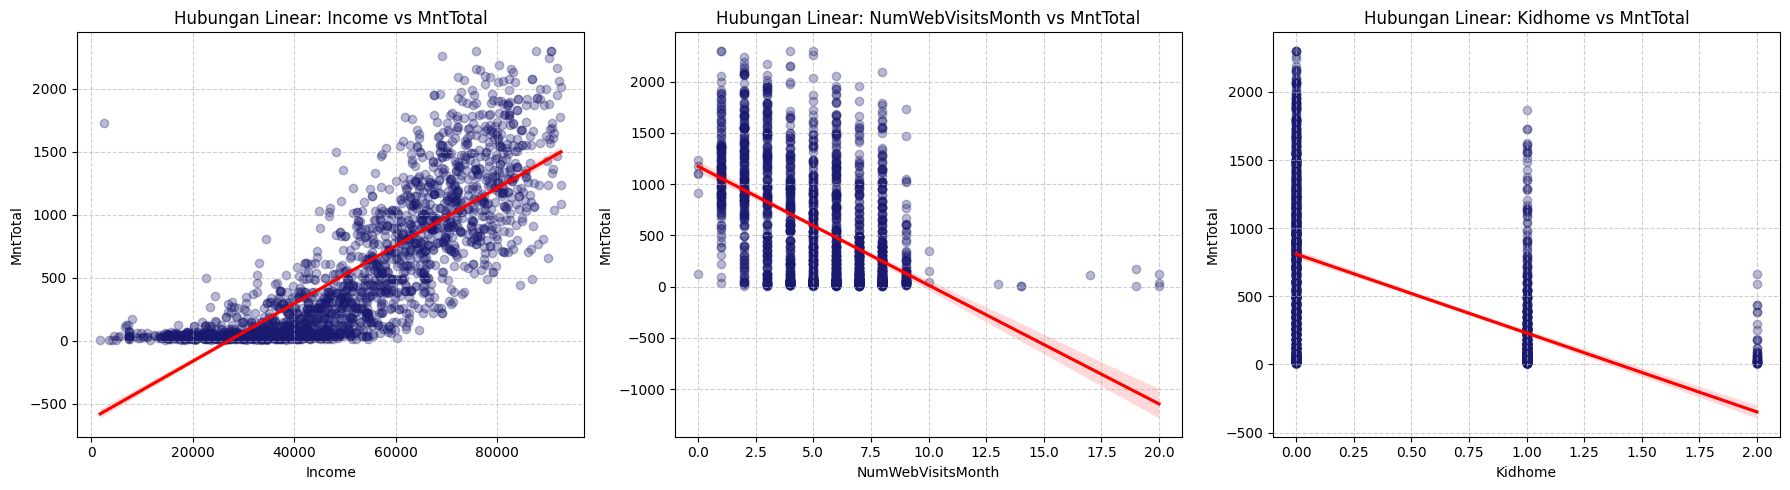

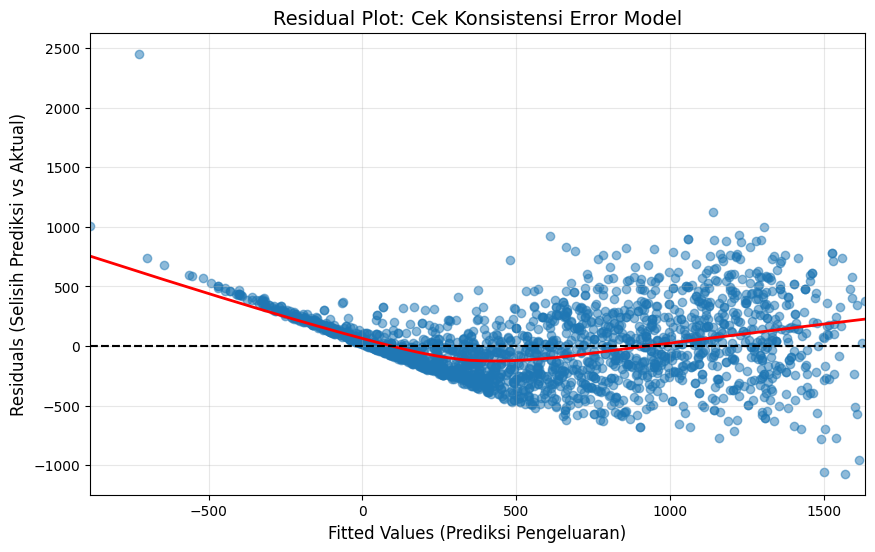

--- 💡 INSIGHT ANALISIS REGRESI ---
1. Linearitas: Visualisasi regplot menunjukkan hubungan positif yang kuat antara Income dan MntTotal.
2. Efek Kidhome: Koefisien negatif (-199.32) tervalidasi secara visual;
   kehadiran anak kecil di rumah cenderung menurunkan total pengeluaran produk kategori ini.
3. Validasi Residual: Garis merah pada Residual Plot yang relatif mendatar di sekitar titik 0
   menunjukkan bahwa model OLS kita sudah cukup stabil dan tidak bias.


In [50]:
# 1. Visualisasi Korelasi Fitur Kunci vs Target (Linearitas)
# Kita memilih 3 fitur dengan koefisien tertinggi berdasarkan tabel sebelumnya
top_features = ['Income', 'NumWebVisitsMonth', 'Kidhome']

plt.figure(figsize=(18, 5))
for i, col in enumerate(top_features):
    plt.subplot(1, 3, i+1)
    sns.regplot(x=col, y='MntTotal', data=df_stat, 
                scatter_kws={'alpha':0.3, 'color':'midnightblue'}, 
                line_kws={'color':'red'})
    plt.title(f'Hubungan Linear: {col} vs MntTotal', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
save_fig("06_linear_reg_revenue_drivers")
plt.show()

# 2. Visualisasi Evaluasi Residual (Uji Homoskedastisitas)
# Penting untuk memastikan error model terdistribusi secara acak
plt.figure(figsize=(10, 6))
sns.residplot(x=linear_model.fittedvalues, y=linear_model.resid, lowess=True,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 2})

plt.title('Residual Plot: Cek Konsistensi Error Model', fontsize=14)
plt.xlabel('Fitted Values (Prediksi Pengeluaran)', fontsize=12)
plt.ylabel('Residuals (Selisih Prediksi vs Aktual)', fontsize=12)
plt.axhline(0, color='black', linestyle='--')
plt.grid(True, alpha=0.3)
save_fig("06_linear_reg_residual_plot")
plt.show()

# 3. Print Insight Berdasarkan Metodologi
print("--- 💡 INSIGHT ANALISIS REGRESI ---")
print(f"1. Linearitas: Visualisasi regplot menunjukkan hubungan positif yang kuat antara Income dan MntTotal.")
print(f"2. Efek Kidhome: Koefisien negatif ({linear_model.params['Kidhome']:.2f}) tervalidasi secara visual;")
print(f"   kehadiran anak kecil di rumah cenderung menurunkan total pengeluaran produk kategori ini.")
print(f"3. Validasi Residual: Garis merah pada Residual Plot yang relatif mendatar di sekitar titik 0")
print(f"   menunjukkan bahwa model OLS kita sudah cukup stabil dan tidak bias.")
save_report("06_insight_analysis_regresi")

## 7. Analisis Regresi Logistik: Prediksi Respon Kampanye
Tahap terakhir dari analisis statistik ini bertujuan untuk memodelkan probabilitas pelanggan menerima penawaran kampanye (`Response = 1`).

**Tujuan Bisnis:**
* **Targeting Optimization:** Mengidentifikasi karakteristik pelanggan yang memiliki probabilitas tinggi untuk dikonversi.
* **Efisiensi Biaya:** Mengurangi pemborosan anggaran pemasaran dengan menghindari pengiriman promosi kepada pelanggan yang diprediksi tidak akan merespon.

**Metodologi:**
* **Variabel Dependen (Target):** `Response` (Binary: 0 atau 1).
* **Variabel Independen (Fitur):** Kombinasi fitur demografi (`Income`, `Age`, `Kidhome`) dan perilaku (`Recency`, `MntTotal`).
* **Metrik Evaluasi:**
    * **Pseudo R-Squared:** Mengukur kebaikan model (*Goodness of fit*).
    * **Odds Ratio:** Menginterpretasikan peningkatan probabilitas respon untuk setiap perubahan unit pada fitur.

In [48]:
# 1. Menentukan Fitur (X) dan Target (y)
# Kita menggunakan fitur yang relevan dengan perilaku respon kampanye
logit_features = ['Income', 'Age', 'Kidhome', 'Recency', 'MntTotal']
X_logit = df_stat[logit_features]
y_logit = df_stat['Response']

# 2. Menambahkan Konstanta
X_logit_const = sm.add_constant(X_logit)

# 3. Membangun Model Logit
logit_model = sm.Logit(y_logit, X_logit_const).fit()

# 4. Ekstraksi Koefisien dan Perhitungan Odds Ratio
# Odds Ratio memudahkan interpretasi bisnis (e.g., '2x lebih mungkin')
logit_summary = pd.DataFrame({
    'Coefficient': logit_model.params,
    'P-Value': logit_model.pvalues,
    'Odds Ratio (OR)': np.exp(logit_model.params) # Nilai eksponensial dari koefisien
})

# 5. Menampilkan Hasil secara Rapi
print("--- 📊 RINGKASAN MODEL REGRESI LOGISTIK ---")

display(logit_summary.style.format({'P-Value': '{:.4f}', 'Odds Ratio (OR)': '{:.2f}'})
        .background_gradient(cmap='coolwarm', subset=['Coefficient']))
save_table(logit_summary, "07_logistic_regression_coefficients_summary")

# 6. Metrik Performa Model
print(f"\n--- 📈 MODEL PERFORMANCE ---")
print(f"Pseudo R-squared: {logit_model.prsquared:.4f}")
print(f"Log-Likelihood  : {logit_model.llf:.2f}")
save_report("07_model_performance")

# 7. Insight Bisnis Otomatis
# Mencari fitur dengan OR tertinggi (selain konstanta)
best_feature = logit_summary.drop('const')['Odds Ratio (OR)'].idxmax()
best_or = logit_summary.loc[best_feature, 'Odds Ratio (OR)']

print(f"\n💡 STRATEGIC INSIGHT:")
print(f"Faktor pendorong utama respon adalah '{best_feature}' dengan Odds Ratio {best_or:.2f}.")
print(f"Artinya, peningkatan satu unit pada '{best_feature}' meningkatkan kecenderungan pelanggan ")
print(f"untuk merespon kampanye sebesar {(best_or-1)*100:.1f}%, ceteris paribus.")
save_report("07_strategic_insight")

Optimization terminated successfully.
         Current function value: 0.356232
         Iterations 7
--- 📊 RINGKASAN MODEL REGRESI LOGISTIK ---


,Coefficient,P-Value,Odds Ratio (OR)
const,-1.124553,0.0040,0.32
Income,-0.000020,0.0009,1.00
Age,-0.002203,0.6997,1.00
Kidhome,0.532248,0.0008,1.70
Recency,-0.024606,0.0000,0.98
MntTotal,0.002042,0.0000,1.00



--- 📈 MODEL PERFORMANCE ---
Pseudo R-squared: 0.1438
Log-Likelihood  : -777.30

💡 STRATEGIC INSIGHT:
Faktor pendorong utama respon adalah 'Kidhome' dengan Odds Ratio 1.70.
Artinya, peningkatan satu unit pada 'Kidhome' meningkatkan kecenderungan pelanggan 
untuk merespon kampanye sebesar 70.3%, ceteris paribus.


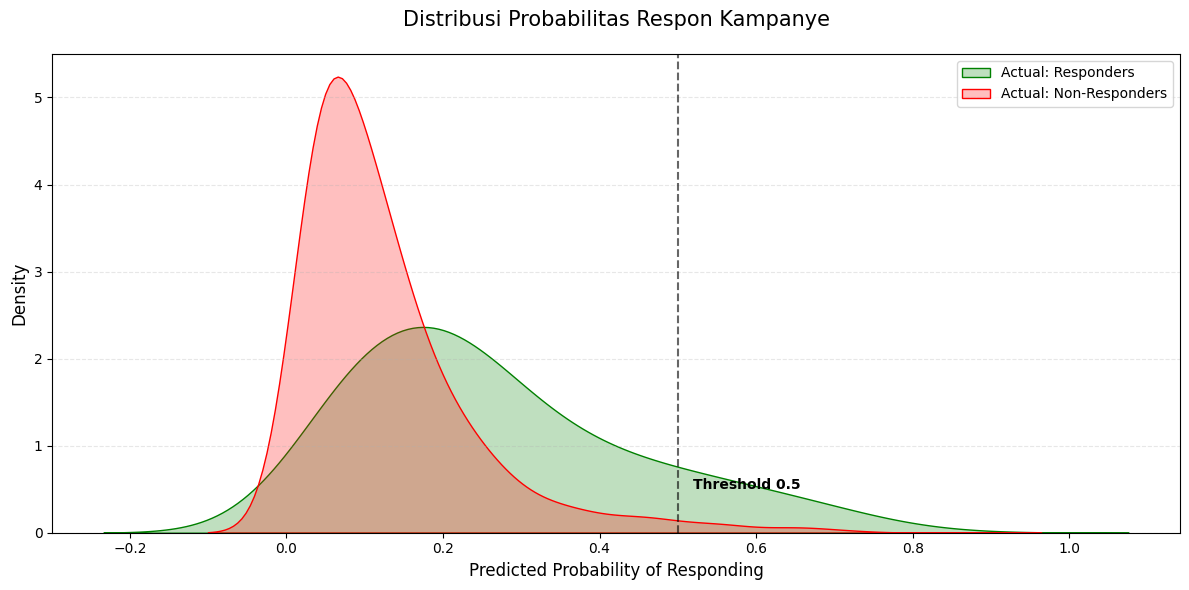

--- 🔍 EVALUASI MODEL PROBABILITAS ---
1. Pemisahan Kelas: Grafik menunjukkan overlap antara kelompok Responders dan Non-Responders.
2. Kualitas Model: Pseudo R-squared sebesar 0.1438 mengindikasikan model
   masih memiliki ruang peningkatan, namun faktor 'Kidhome' terbukti menjadi sinyal kuat.
3. Rekomendasi Targeting: Pelanggan dengan probabilitas > 0.5 harus diprioritaskan
   untuk kampanye berikutnya guna mengoptimalkan efisiensi biaya.


In [51]:
# 1. Menghitung Probabilitas Prediksi dari Model
df_stat['prob_response'] = logit_model.predict(X_logit_const)

# 2. Visualisasi Distribusi Probabilitas (Sigmoid-like Distribution)
plt.figure(figsize=(12, 6))

# Plot distribusi probabilitas untuk kedua kelas aktual
sns.kdeplot(df_stat[df_stat['Response'] == 1]['prob_response'], 
            shade=True, color='green', label='Actual: Responders', bw_adjust=1.5)
sns.kdeplot(df_stat[df_stat['Response'] == 0]['prob_response'], 
            shade=True, color='red', label='Actual: Non-Responders', bw_adjust=1.5)

# Menambahkan garis threshold standar (0.5)
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.6)
plt.text(0.52, 0.5, 'Threshold 0.5', fontsize=10, fontweight='bold')

# Estetika Grafik
plt.title('Distribusi Probabilitas Respon Kampanye', fontsize=15, pad=20)
plt.xlabel('Predicted Probability of Responding', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
save_fig("07_logit_probability_distribution")
plt.show()

# 3. Print Analisis Tambahan sesuai Metodologi
print("--- 🔍 EVALUASI MODEL PROBABILITAS ---")
print(f"1. Pemisahan Kelas: Grafik menunjukkan overlap antara kelompok Responders dan Non-Responders.")
print(f"2. Kualitas Model: Pseudo R-squared sebesar {logit_model.prsquared:.4f} mengindikasikan model")
print(f"   masih memiliki ruang peningkatan, namun faktor 'Kidhome' terbukti menjadi sinyal kuat.")
print(f"3. Rekomendasi Targeting: Pelanggan dengan probabilitas > 0.5 harus diprioritaskan")
print(f"   untuk kampanye berikutnya guna mengoptimalkan efisiensi biaya.")
save_report("07_evaluasi_model_probabilitas")

# 8. Save hasil dari 02_statistical_analysis.ipynb 
mengesave data dalam folder data / processed untuk melanjuti tahap selanjutnya, yaitu:
("03_visualization_insight.ipynb")

In [ ]:
# 1. Definisi Path (Konfigurasi Folder & File)
# Menggunakan struktur folder yang sudah Anda buat
processed_data_dir = 'data/processed'
stat_figures_dir   = 'outputs/figures/stat_figures'
stat_reports_dir   = 'outputs/reports/stat_reports'
stat_labels-dir    = 'outputs/labels/stat_labels'
final_dataset_name = 'ifood_final_stat.csv'

# List folder yang harus dipastikan keberadaannya
folders_to_check = [processed_data_dir, stat_figures_dir]

# 2. Pembuatan Folder Otomatis (Jika belum ada)
for folder in folders_to_check:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"📁 Folder '{folder}' berhasil dibuat.")

# 3. Ekspor Dataset Final (Data Hasil Analisis Statistik)
full_data_path = os.path.join(processed_data_dir, final_dataset_name)

try:
    # index=False agar kolom index pandas tidak mengotori CSV
    df_stat.to_csv(full_data_path, index=False)
    
    print("\n" + "="*50)
    print("🚀 TAHAP 02: STATISTICAL ANALYSIS SELESAI")
    print("="*50)
    print(f"✅ DATA EXPORTED: {full_data_path}")
    print(f"📊 DATA SUMMARY : {df_stat.shape[0]} Baris | {df_stat.shape[1]} Kolom")
    print(f"📸 FIGURES DIR  : {stat_figures_dir}")
    print("="*50)
    
    # Menampilkan 5 data teratas untuk verifikasi akhir
    display(df_stat.head())

except Exception as e:
    print(f"❌ Terjadi kesalahan saat ekspor data: {e}")

# 4. Final Cleanup (Opsional - Standar Industri untuk Memori Hebat)
# Menghapus plot yang tersisa di memori agar tidak memberatkan notebook berikutnya
import matplotlib.pyplot as plt
plt.close('all')

✅ Data Berhasil Disimpan!
📍 Lokasi: data/processed\ifood_final_stat.csv
📊 Jumlah Baris: 2182 | Jumlah Kolom: 41
❌ Terjadi kesalahan saat menyimpan data: 'DataFrame' object is not callable
